<a href="https://colab.research.google.com/github/davichomendez1901-byte/Simulaci-n/blob/main/Flecha_Cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resolveremos el problema a partir de los datos dados en la imagen y los que fueron obtenidos de  manera analítica

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm #Para analizar la normal
#Datos:
var_X1 = 0.0016
mu_X1 = 1.5
var_X2 = 0.0009
mu_X2 = 1.48
#Ahora calculamos la media y la var de D = x2-x1
D_var = var_X1 + var_X2
D_mu = mu_X2 - mu_X1
#Desviación estandar:
sig_D = np.sqrt(D_var)
#calculamos el valor de Z
z = (0-D_mu)/sig_D
#La probabilidad de interferencia entonces sería:
p = 1 - norm.cdf(z)
print("Media de D", D_mu)
print("Varianza de D",D_var)
print("Desviación estandar de D", sig_D)
print("Valor de Z", z)
print("Probabilidad de interferencia", p*100)

Media de D -0.020000000000000018
Varianza de D 0.0025
Desviación estandar de D 0.05
Valor de Z 0.40000000000000036
Probabilidad de interferencia 34.45782583896757


In [2]:
Z_alpha = 1.96 #Nivel de conffinaza
E = 0.01       #Error maximo permitido
# tamaño de muestra:
n = Z_alpha**2 * p * (1-p) /E**2
print("Son necesarias ", n)
#

Son necesarias  8676.026263132599


In [4]:
# Número de simulaciones
N = 100000

# Generaremos muestras aleatorias para X1 y X2
# Usamos la desviación estándar
new_X1 = np.random.normal(mu_X1, np.sqrt(var_X1), N)
new_X2 = np.random.normal(mu_X2, np.sqrt(var_X2), N)

samples_D = new_X2 - new_X1

# Contar cuántas veces D > 0 (interferencia)
Num_interferencias = np.sum(samples_D > 0)

# Calcular la probabilidad de interferencia simulada
inter_simu = Num_interferencias / N
print(f"Número de simulaciones: {N}")
print(f"Recuento de interferencias: {Num_interferencias}")
print(f"Probabilidad de interferencia simulada: {inter_simu:.4f}")
print(f"Probabilidad analítica (p): {p:.4f}")

Número de simulaciones: 100000
Recuento de interferencias: 34496
Probabilidad de interferencia simulada: 0.3450
Probabilidad analítica (p): 0.3446


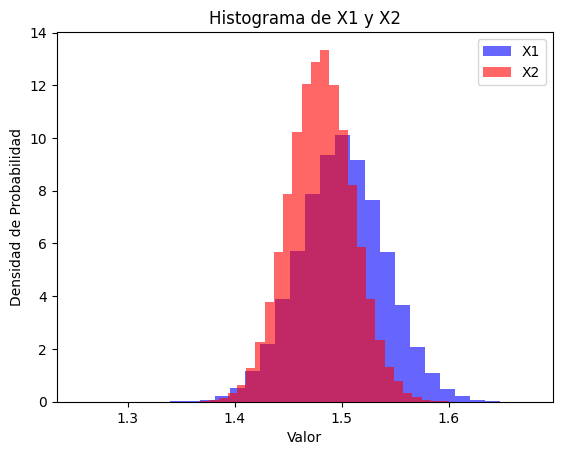

In [5]:
#Gaficando:
plt.hist(new_X1, bins=30, density=True, alpha=0.6, color='b', label='X1')
plt.hist(new_X2, bins=30, density=True, alpha=0.6, color='r', label='X2')
plt.xlabel('Valor')
plt.ylabel('Densidad de Probabilidad')
plt.title('Histograma de X1 y X2')
plt.legend()
plt.show()